In [51]:
# Cell 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [52]:
# Cell 2: Load dataset
import os
import urllib.request

filename = 'Position_Salaries.csv'
if not os.path.exists(filename):
    url = 'https://raw.githubusercontent.com/iksasa15/AI-ML/main/code/3-%20Polynomial%20Linear%20Regression/Position_Salaries.csv'
    urllib.request.urlretrieve(url, filename)

dataset = pd.read_csv(filename)
dataset


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [53]:
# Cell 3: Select features and target
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values


In [54]:
# Cell 4: Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
# Cell 5: Train Polynomial Regression model
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
# Cell 6: Predict all values for evaluation (Linear vs Polynomial)
y_pred_linear = lin_reg.predict(X)
y_pred_poly = lin_reg_2.predict(poly_reg.fit_transform(X))


In [57]:
# Cell 7: Calculate Performance Metrics
# Linear Regression Metrics
r2_lin = r2_score(y, y_pred_linear)
mse_lin = mean_squared_error(y, y_pred_linear)
mae_lin = mean_absolute_error(y, y_pred_linear)
print("Linear Regression Metrics:")
print(f"R-squared: {r2_lin:.4f}")
print(f"MSE: {mse_lin:.4f}")
print(f"MAE: {mae_lin:.4f}")
print("-" * 30)
# Polynomial Regression Metrics
r2_poly = r2_score(y, y_pred_poly)
mse_poly = mean_squared_error(y, y_pred_poly)
mae_poly = mean_absolute_error(y, y_pred_poly)
print("Polynomial Regression Metrics:")
print(f"R-squared: {r2_poly:.4f}")
print(f"MSE: {mse_poly:.4f}")
print(f"MAE: {mae_poly:.4f}")


Linear Regression Metrics:
R-squared: 0.6690
MSE: 26695878787.8788
MAE: 128454.5455
------------------------------
Polynomial Regression Metrics:
R-squared: 0.9974
MSE: 210343822.8438
MAE: 12681.8182


In [58]:
# Cell 8: Predict a new salary at level 6.5
pred_lin = lin_reg.predict([[6.5]])
pred_poly = lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))
print(f"Linear Regression Prediction for 6.5: {pred_lin[0]:.2f}")
print(f"Polynomial Regression Prediction for 6.5: {pred_poly[0]:.2f}")


Linear Regression Prediction for 6.5: 330378.79
Polynomial Regression Prediction for 6.5: 158862.45


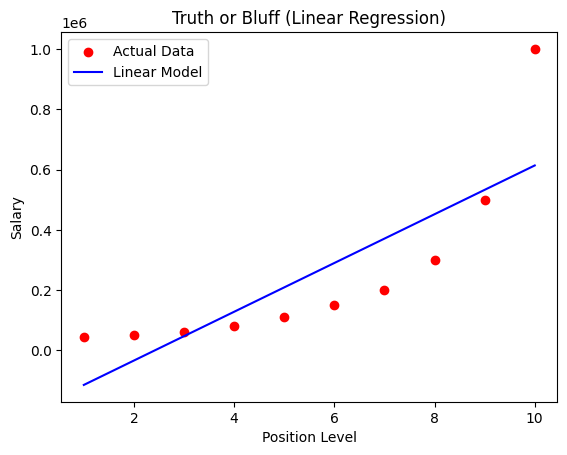

In [59]:
# Cell 9: Visualize the Linear Regression results
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X, lin_reg.predict(X), color='blue', label='Linear Model')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()


/var/folders/8z/j3pgyqkn5k11cv456vdv65gc0000gp/T/ipykernel_33065/2344926212.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)


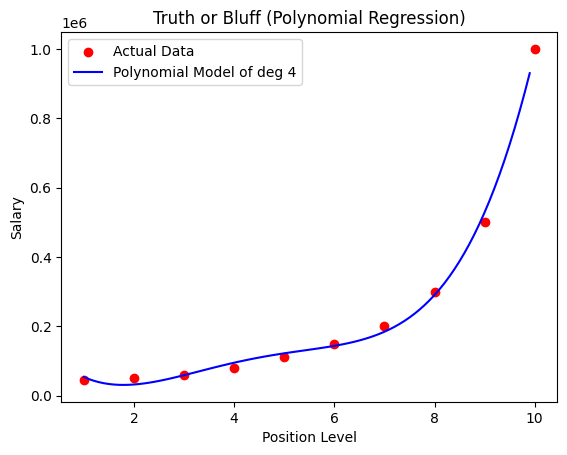

In [60]:
# Cell 10: Visualize the Polynomial Regression results (Higher Resolution & Smooth Curve)
X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color='blue', label='Polynomial Model of deg 4')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()
